# Challenge TelecomX - Alura LATAM

Alumno: Cristian Velásquez Rios

#📌 Extracción
En esta sección:
- Se realiza importación de las librerías necesarias.
- Se carga el dataset en formato JSON desde una URL, para mantener fuente de datos.
- Se convierten los datos a un DataFrame de Pandas para comenzar el análisis.

In [285]:
# ======================================
# 1. Importar librerías y cargar dataset
# ======================================
import requests
import pandas as pd
import numpy as np
import json

# Se carga el JSON desde URL
url = "https://raw.githubusercontent.com/sthemonica/alura-voz/refs/heads/main/Dados/Telco-Customer-Churn.json"
response = requests.get(url)
data = response.json()

# Convertir a DataFrame
df_inicial = pd.DataFrame(data)

# Vista inicial
print("Vista previa de los datos:")
df_inicial.head()

Vista previa de los datos:


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación
En esta etapa:
- Se valida la estructura y tipos de datos.
- Se examina si existen valores nulos, duplicados y errores.
- Se realizan correcciones: conversión de tipos de dato y limpieza.

In [286]:
# En la vista previa de los datos nos damos cuenta que el contenido del df no está separado en registros únicos
# Debemos normalizar los datos para separar en columnas
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [287]:
# Análisis inicial y limpieza

# En la vista previa de los datos nos damos cuenta que el contenido tiene columnas con registros múltiples
# Debemos normalizar los datos para separar en columnas

df = pd.json_normalize(data)
df

# Información general
print("\nInformación del DataFrame:\n")
print(df.info())

# Comprobar si existen valores nulos
print("\nValores nulos por columna:\n")
print(df.isnull().sum())

# Verificar si existen valores duplicados
print("\nNúmero de registros duplicados:\n")
print(df.duplicated().sum())

# Verificar registros vacíos o en blanco
print("\nNúmero de registros vacíos o en blanco:\n")
print(df.apply(lambda x: x.astype(str).str.strip() == '').sum())

# Verificar y mostrar valores únicos en cada columna
print("\nValores únicos por columna:\n")
for col in df.columns:
  print('-' * 50)  # Línea divisoria
  print(f"valores únicos en la columna'{col}': {df[col].nunique()}")
  if df[col].nunique() < 50: # Imprime los valores solamente si son <50
    print(df[col].unique())

# Convertir la columna "account.Charges.Total" a tipo float, identificando valores no válidos
print("Convertir la columna 'account.Charges.Total' a tipo float:")
print(f"Valores únicos antes de conversión: {df['account.Charges.Total'].nunique()}")
print(f"Ejemplo de valores: {df['account.Charges.Total'].head()}")

# Convertir a numérico, los valores no válidos se convierten en NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Verificar si la conversión generó valores nulos
nulos = df['account.Charges.Total'].isnull().sum()
print(f"\nNúmero de valores nulos después de conversión: {nulos}")

# Si hay valores nulos, decidir estrategia de imputación
if nulos > 0:
    print(f"Porcentaje de valores nulos: {(nulos/len(df))*100:.2f}%")

    # Analizar si los nulos tienen un patrón
    print("\nAnálisis de registros con cargos_totales nulos:")
    registros_nulos = df[df['account.Charges.Total'].isnull()]
    print(f"Antigüedad promedio de registros nulos: {registros_nulos['customer.tenure'].mean():.1f} meses")

    # Estrategia 1: Imputar con la media (solo si <5% de nulos)
    if (nulos/len(df)) < 0.05:
        media_cargos = df['account.Charges.Total'].mean()
        df['account.Charges.Total'] = df['account.Charges.Total'].fillna(media_cargos)
        print(f"Valores nulos imputados con la media: ${media_cargos:.2f}")

    # Estrategia 2: Imputar basado en antigüedad y cargos mensuales
    else:
        # Para registros con poca antigüedad, usar cargos mensuales * meses
        mask_nulos = df['account.Charges.Total'].isnull()
        df.loc[mask_nulos, 'account.Charges.Total'] = (
            df.loc[mask_nulos, 'account.Charges.Monthly'] * df.loc[mask_nulos, 'customer.tenure']
        )
        print("Valores nulos imputados usando: cargos_mensuales × antigüedad")

else:
    print("No se encontraron valores nulos después de la conversión")

# Verificar resultado final
print(f"\nDatos finales de cargos_totales:")
print(f"Tipo de dato: {df['account.Charges.Total'].dtype}")
print(f"Valores nulos restantes: {df['account.Charges.Total'].isnull().sum()}")
print(f"Estadísticas descriptivas:")
print(df['account.Charges.Total'].describe())

# Validación lógica (cargos totales >= cargos mensuales)
inconsistencias = df[df['account.Charges.Total'] < df['account.Charges.Monthly']]
if len(inconsistencias) > 0:
    print(f"\nADVERTENCIA: {len(inconsistencias)} registros con cargos_totales < cargos_mensuales")
    print("Estos registros requieren revisión manual o corrección adicional")
else:
    print("\nValidación exitosa: No hay inconsistencias lógicas en los cargos")


Información del DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSuppor

In [288]:
# A partir del análisis inicial, vemos que hay 224 registros en blanco para la columna Churn (~3% del dataset)
# Los datos faltantes están en la variable objetivo 'Churn'
# No se puede predecir o clasificar un valor si no conocemos su etiqueta.
# Imputar Churn (Yes/No) con valores ficticios introduciría sesgo en el análisis.
# El porcentaje es bajo (<5%), por lo que se considera sesgo introducido como mínimo.
# Por lo tanto, se toma la decisión de eliminar estos registros del dataframe

# Eliminando los registros de Churn vacíos
# Contar registros originales
total_registros = len(df)

# Filtrar filas válidas (no nulas y no vacías)
df = df[df['Churn'].notnull() & (df['Churn'].str.strip() != '')]

# Contar registros restantes
registros_restantes = len(df)
eliminados = total_registros - registros_restantes
porcentaje_eliminado = (eliminados / total_registros) * 100

print(f"Número de registros eliminados: {eliminados}")
print(f"Porcentaje eliminado: {porcentaje_eliminado:.2f}%")
print(f"Registros restantes: {registros_restantes}")


Número de registros eliminados: 224
Porcentaje eliminado: 3.08%
Registros restantes: 7043


In [289]:
# Usamos el método describe para revisar estadísticas de las columnas con datos de tipo numérico
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.296277
std,0.368612,24.559481,30.090047,2265.000260
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1400.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [290]:
# Crear columna 'Cuentas_Diarias'
df = df.copy()  # Copia de seguridad del df
df.loc[:, 'Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30

# Validar la nueva columna
print("\nVista previa con columna 'Cuentas_Diarias':")
print(df[['account.Charges.Monthly', 'Cuentas_Diarias']].head())


Vista previa con columna 'Cuentas_Diarias':
   account.Charges.Monthly  Cuentas_Diarias
0                     65.6         2.186667
1                     59.9         1.996667
2                     73.9         2.463333
3                     98.0         3.266667
4                     83.9         2.796667


In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [292]:
# Estandarización y transformación de datos
# Nombres de columnas largos y poco claros. Se alinearán con el diccionario de datos
# Nuevo diccionario para renombrar columnas a español
# Mantenemos la columna Churn y Cuentas_Diarias para efectos de consistencia


# Crear copia segura del df
df = df.copy()

columnas_renombradas = {
    'customerID': 'id_cliente',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'adulto_mayor',
    'customer.Partner': 'tiene_pareja',
    'customer.Dependents': 'tiene_dependientes',
    'customer.tenure': 'meses_contrato',
    'phone.PhoneService': 'servicio_telefonico',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'servicio_internet',
    'internet.OnlineSecurity': 'seguridad_en_linea',
    'internet.OnlineBackup': 'respaldo_en_linea',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'tv_streaming',
    'internet.StreamingMovies': 'peliculas_streaming',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_electronica',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'cargos_mensuales',
    'account.Charges.Total': 'cargos_totales',
}

print("\nNormalización de datos y renombrado de columnas:\n")

# Aplicar renombrado
df = df.rename(columns=columnas_renombradas)

# Verificar df actualizado
print(df.info())


# Normalización de valores
# Transformar columnas binarias con Yes/No a valores 1/0

# Columnas binarias (Yes/No a valores 1/0)
binarias = ['tiene_pareja', 'tiene_dependientes', 'servicio_telefonico', 'factura_electronica', 'Churn']
for col in binarias:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Género: Male/Female a valores binarios 1/0
df['genero'] = df['genero'].map({'Male': 1, 'Female': 0})

# Conversión de columnas binarias a tipo entero
df[binarias] = df[binarias].astype('int64')
df['genero'] = df['genero'].astype('int64')

# Limpiar texto en columnas multiclase y dejar en minusculas
categorias = ['tipo_contrato', 'metodo_pago', 'servicio_internet', 'multiples_lineas']
for col in categorias:
    df[col] = df[col].str.strip().str.lower()

# 4. Validación de cambios
print("\nTipos de datos después de la transformación:")
print(df.dtypes)
print("\nVista previa:")
print(df.info())
print(df.head(10))

# Verificar y mostrar valores únicos en cada columna
print("\nValores únicos por columna:\n")
for col in df.columns:
  print('-' * 50)  # Línea divisoria
  print(f"valores únicos en la columna'{col}': {df[col].nunique()}")
  if df[col].nunique() < 50: # Imprime los valores solamente si son <50
    print(df[col].unique())

# Verificacion final df completo normalizado
print("Tipos de datos después de la transformación:")
print(df.dtypes)
print("\nVista previa de los datos normalizados:")
print(df.head(5))
print("\nInformación del df completo normalizado:\n")
print(df.info())


Normalización de datos y renombrado de columnas:

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7043 non-null   object 
 1   Churn                   7043 non-null   object 
 2   genero                  7043 non-null   object 
 3   adulto_mayor            7043 non-null   int64  
 4   tiene_pareja            7043 non-null   object 
 5   tiene_dependientes      7043 non-null   object 
 6   meses_contrato          7043 non-null   int64  
 7   servicio_telefonico     7043 non-null   object 
 8   multiples_lineas        7043 non-null   object 
 9   servicio_internet       7043 non-null   object 
 10  seguridad_en_linea      7043 non-null   object 
 11  respaldo_en_linea       7043 non-null   object 
 12  proteccion_dispositivo  7043 non-null   object 
 13  soporte_tecnico         7043 non-null   object 

#📊 Carga y análisis
*   Se realiza un análisis descriptivo de los datos
*   Análisis de distribución para la variable Churn
*   Análisis y visualización de variables numéricas y categóricas asociadas
*   Extracción de conclusiones e insights
*   Establecer recomendaciones en base al análisis realizado

In [293]:
# Revisamos la composición del df normalizado
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7043 non-null   object 
 1   Churn                   7043 non-null   int64  
 2   genero                  7043 non-null   int64  
 3   adulto_mayor            7043 non-null   int64  
 4   tiene_pareja            7043 non-null   int64  
 5   tiene_dependientes      7043 non-null   int64  
 6   meses_contrato          7043 non-null   int64  
 7   servicio_telefonico     7043 non-null   int64  
 8   multiples_lineas        7043 non-null   object 
 9   servicio_internet       7043 non-null   object 
 10  seguridad_en_linea      7043 non-null   object 
 11  respaldo_en_linea       7043 non-null   object 
 12  proteccion_dispositivo  7043 non-null   object 
 13  soporte_tecnico         7043 non-null   object 
 14  tv_streaming            7043 non-null   objec

In [294]:
# Análisis descriptivo y estadístico global del df
print("Resumen estadístico global:")
print(df.describe())

# Métricas específicas por Churn
var_numericas = ['meses_contrato', 'cargos_mensuales', 'cargos_totales', 'Cuentas_Diarias']

print("\nEstadísticas descriptivas por Churn:")
for col in var_numericas:
    media_no = df[df['Churn'] == 0][col].mean()
    media_si = df[df['Churn'] == 1][col].mean()
    mediana_no = df[df['Churn'] == 0][col].median()
    mediana_si = df[df['Churn'] == 1][col].median()
    print(f"\n{col.upper()}")
    print(f"  No Churn -> Media: {media_no:.2f}, Mediana: {mediana_no:.2f}")
    print(f"  Churn    -> Media: {media_si:.2f}, Mediana: {mediana_si:.2f}")


Resumen estadístico global:
             Churn       genero  adulto_mayor  tiene_pareja  \
count  7043.000000  7043.000000   7043.000000   7043.000000   
mean      0.265370     0.504756      0.162147      0.483033   
std       0.441561     0.500013      0.368612      0.499748   
min       0.000000     0.000000      0.000000      0.000000   
25%       0.000000     0.000000      0.000000      0.000000   
50%       0.000000     1.000000      0.000000      0.000000   
75%       1.000000     1.000000      0.000000      1.000000   
max       1.000000     1.000000      1.000000      1.000000   

       tiene_dependientes  meses_contrato  servicio_telefonico  \
count         7043.000000     7043.000000          7043.000000   
mean             0.299588       32.371149             0.903166   
std              0.458110       24.559481             0.295752   
min              0.000000        0.000000             0.000000   
25%              0.000000        9.000000             1.000000   
50%     

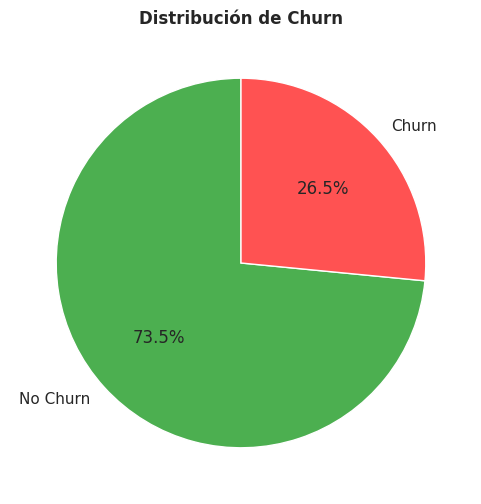

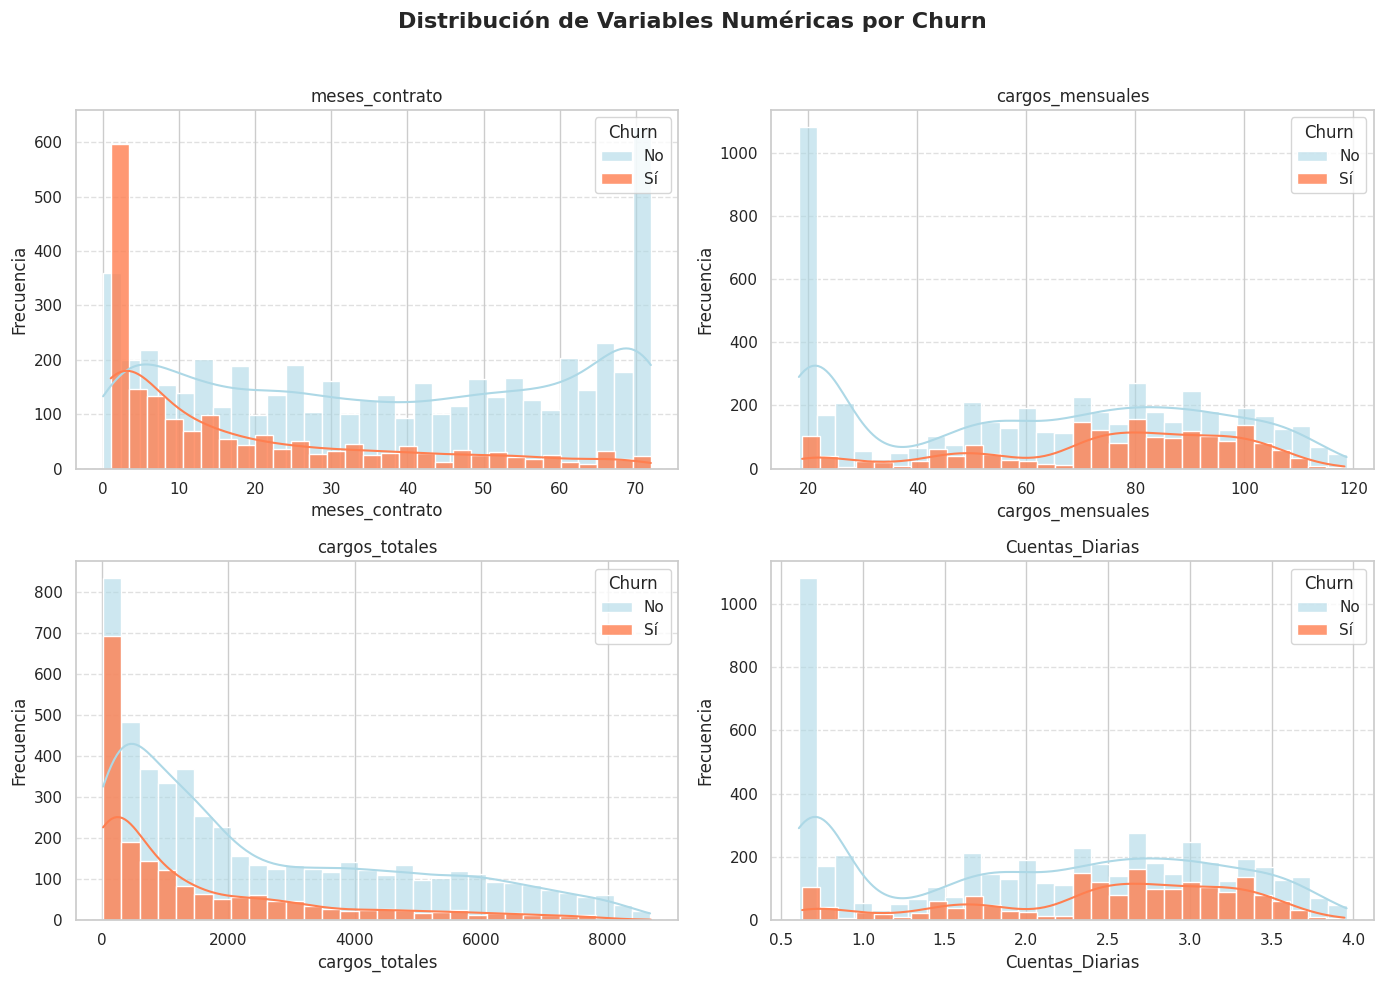

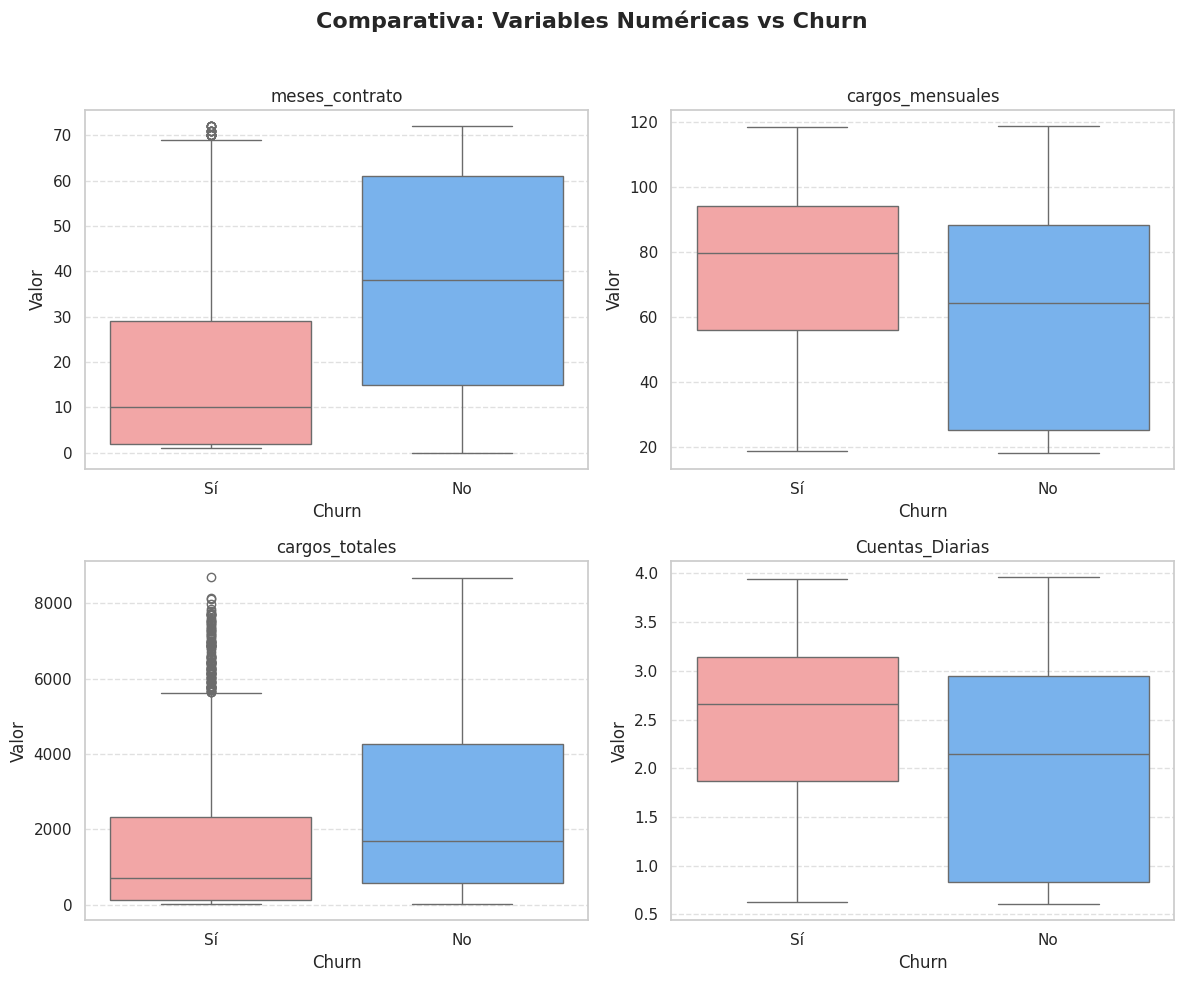

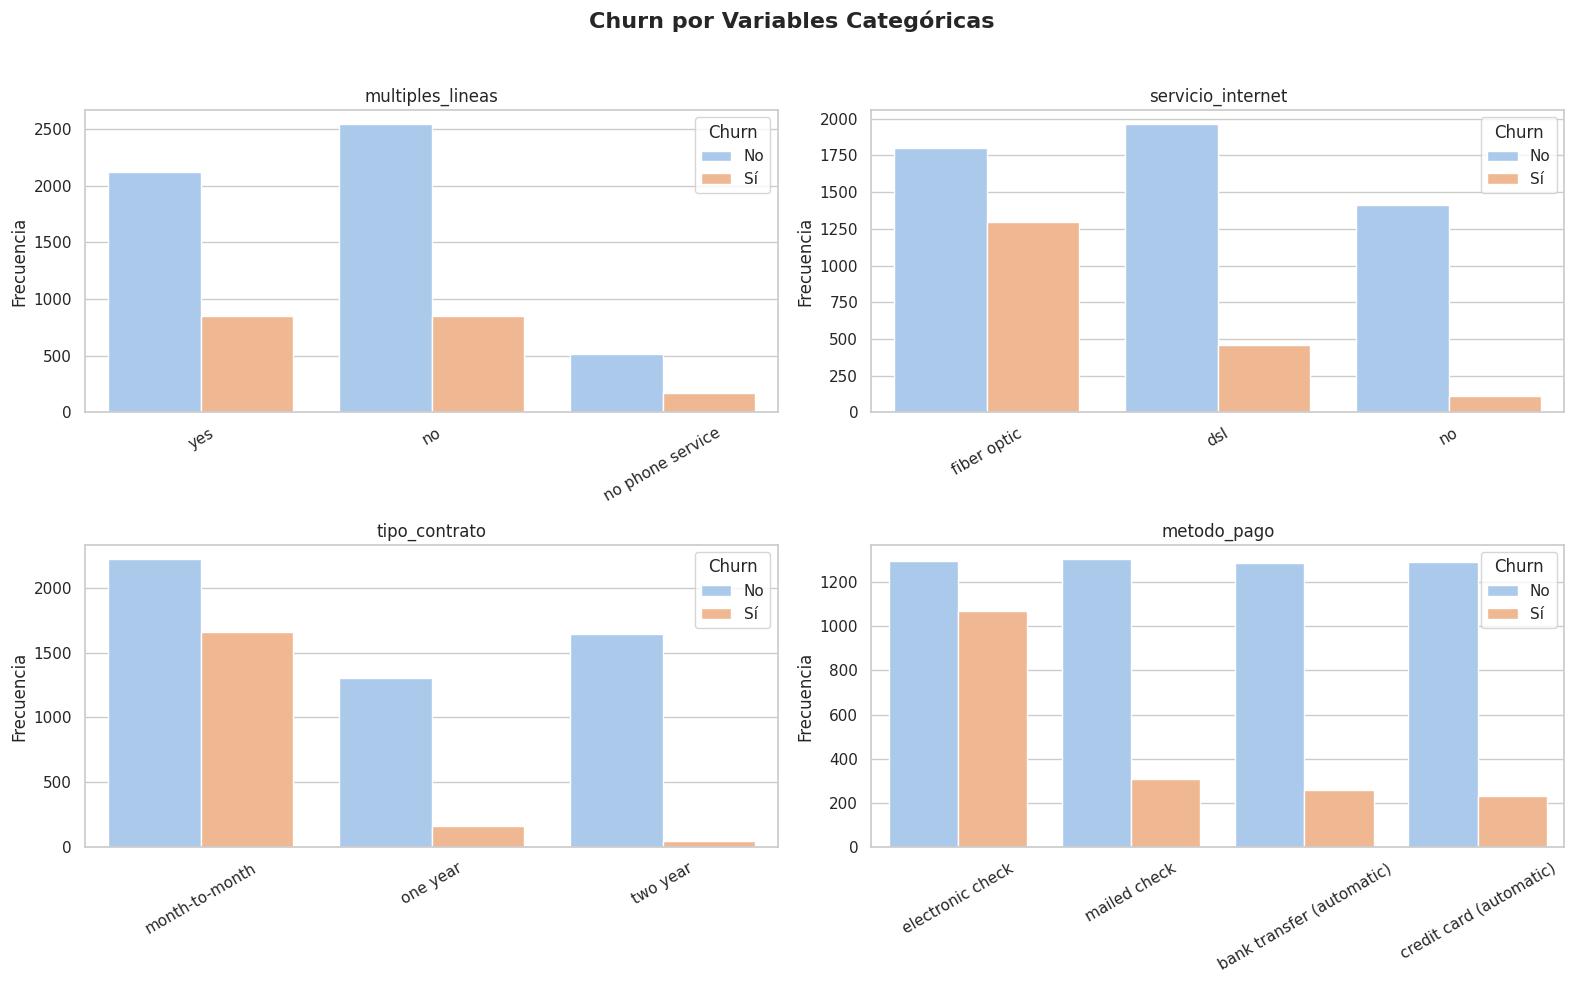

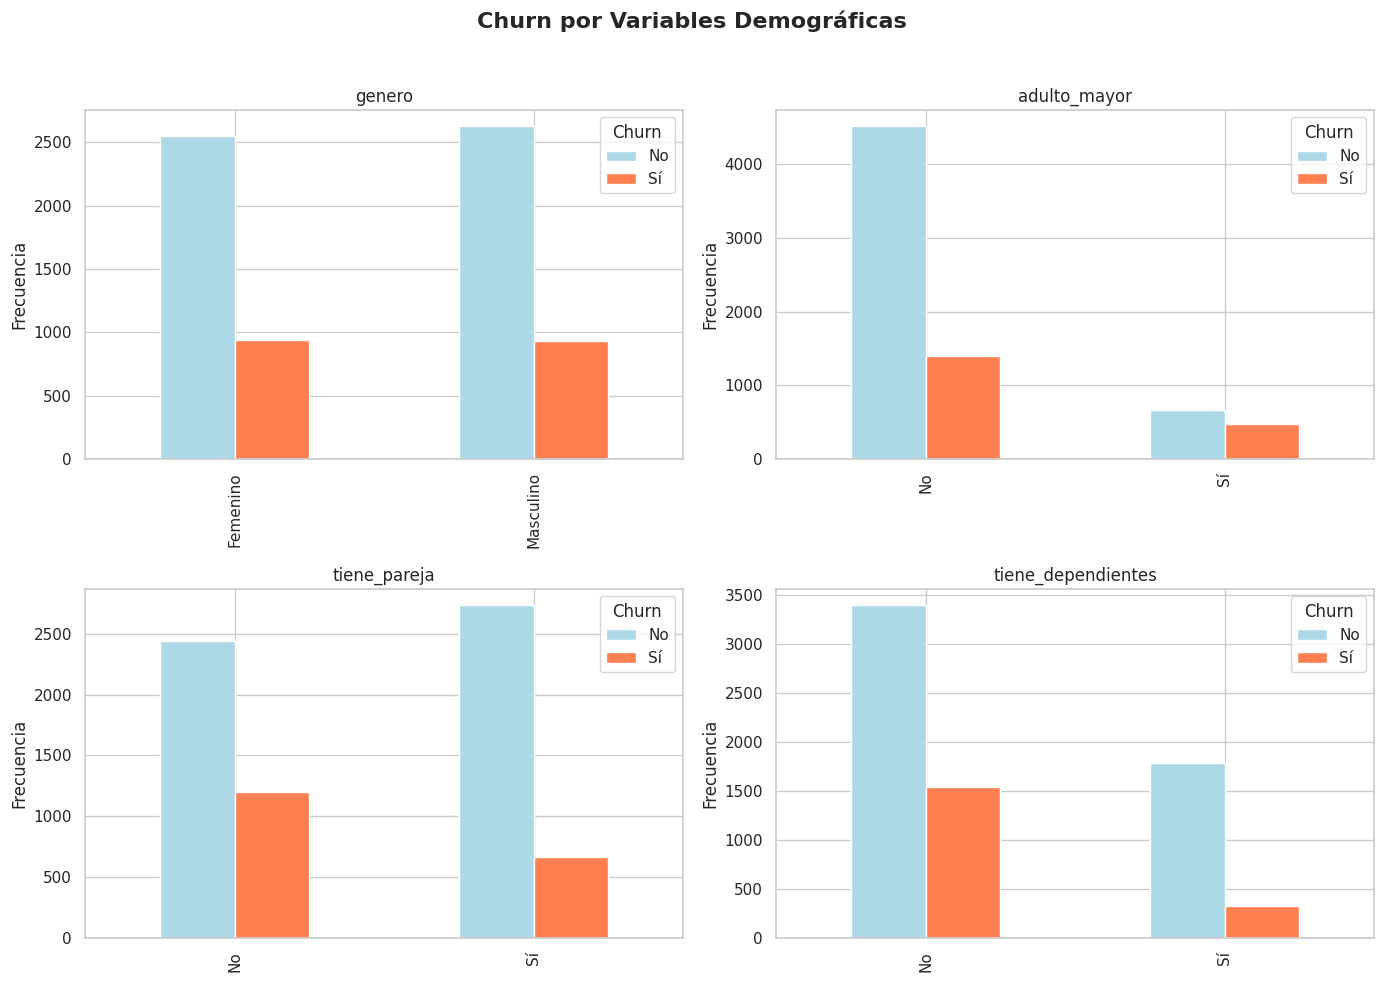

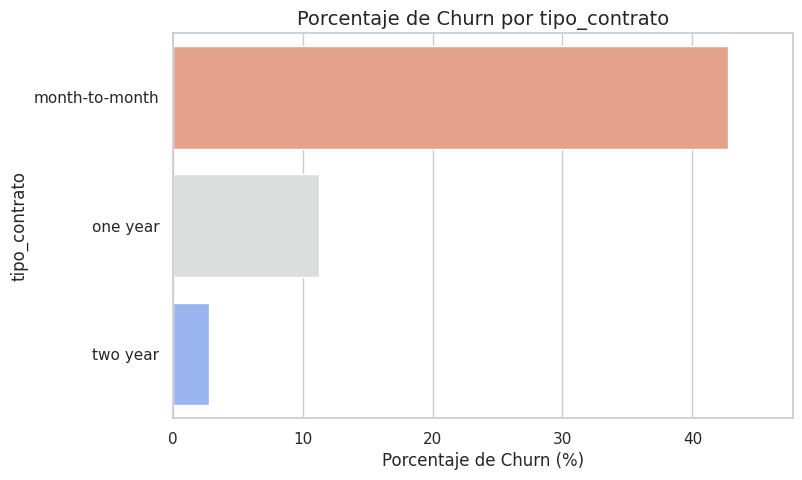

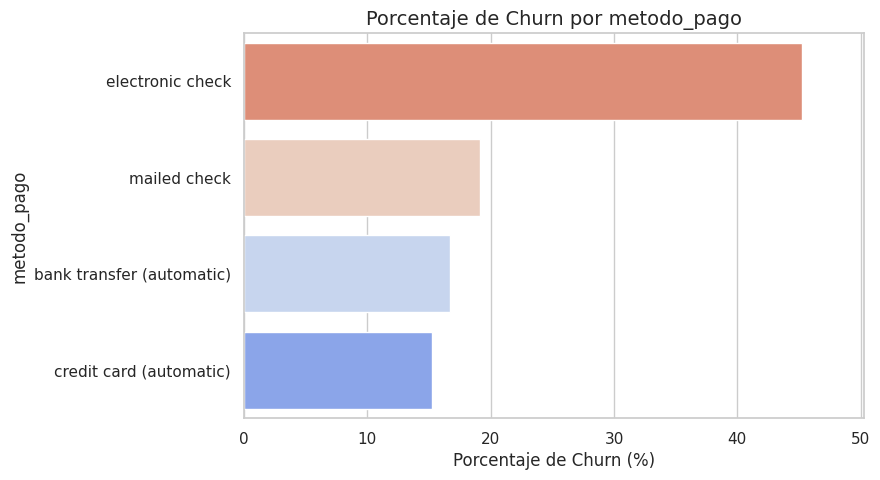

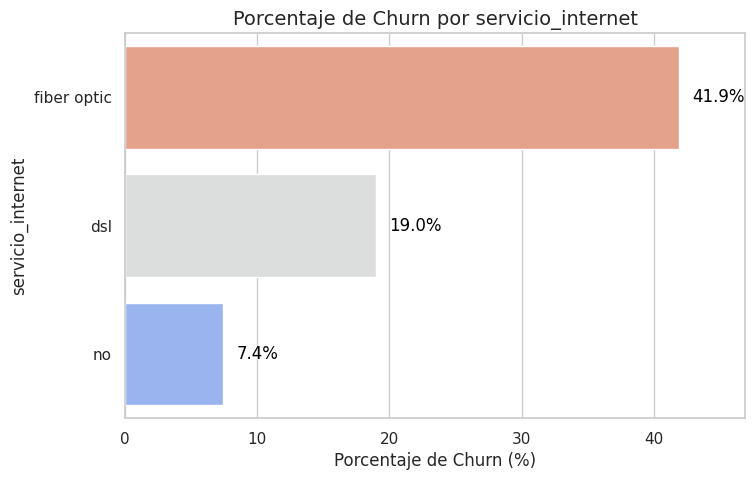

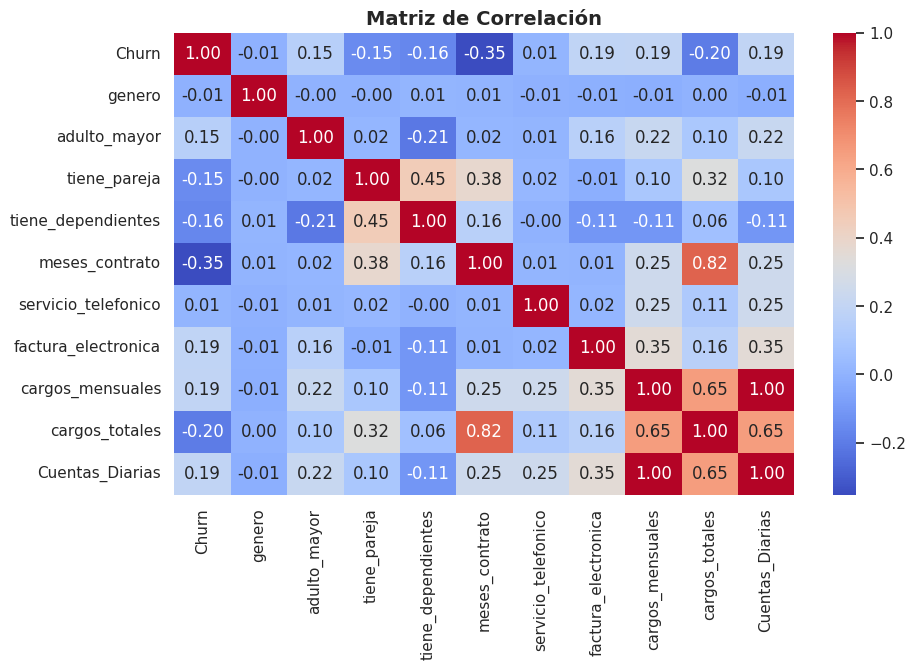

In [295]:
# Generación de múltiples gráficos para visualizar distribución de datos
# Análisis de variables asociadas al Churn

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Distribución de Churn (gráfico tipo cake)
plt.figure(figsize=(6, 6))
df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    labels=['No Churn', 'Churn'],
    colors=['#4CAF50', '#FF5252']
)
plt.title('Distribución de Churn',fontweight='bold')
plt.ylabel('')
plt.show()

# Línea de separación entre gráficos
print("\n")

# Histogramas para variables numéricas
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramas en matriz 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Numéricas por Churn', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(var_numericas):
    # Crear histograma con alpha para transparencia y mejor visualización
    sns.histplot(data=df[df['Churn'] == 0], x=col, kde=True,
                 color='lightblue', alpha=0.6, bins=30, ax=axes[i],
                 label='No')
    sns.histplot(data=df[df['Churn'] == 1], x=col, kde=True,
                 color='coral', alpha=0.8, bins=30, ax=axes[i],
                 label='Sí')

    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
    axes[i].legend(title='Churn', loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Línea de separación entre gráficos
print("\n")

# Gráficos 2x2: Boxplots para variables numéricas

var_numericas = ['meses_contrato', 'cargos_mensuales', 'cargos_totales', 'Cuentas_Diarias']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparativa: Variables Numéricas vs Churn', fontsize=16, fontweight='bold')

axes = axes.flatten()
orden = [1, 0]  # Primero Sí, luego No
palette = {1: '#FF9999', 0: '#66B2FF'}  # Colores fijos: Sí = salmón, No = azul

for i, col in enumerate(var_numericas):
    sns.boxplot(x='Churn', y=col, data=df, hue='Churn',
                order=orden, hue_order=orden, palette=palette,
                legend=False, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Sí', 'No'])
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel('Valor')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Línea de separación entre gráficos
print("\n")

# Gráficos 2x2: Churn por variables categóricas, (ordenadas por tasa de Churn)
categoricas = ['multiples_lineas', 'servicio_internet', 'tipo_contrato', 'metodo_pago']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Churn por Variables Categóricas', fontsize=16, fontweight='bold')

axes = axes.flatten()
for i, col in enumerate(categoricas):
    # Calcular tasa de Churn por categoría
    orden = df.groupby(col)['Churn'].mean().sort_values(ascending=False).index

    # Gráfico ordenado
    sns.countplot(x=col, hue='Churn', data=df, hue_order=[0, 1],
                  order=orden, palette='pastel', ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(title='Churn', labels=['No', 'Sí'])
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Línea de separación entre gráficos
print("\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Variables binarias
categoricas_binarias = ['genero', 'adulto_mayor', 'tiene_pareja', 'tiene_dependientes']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn por Variables Demográficas', fontsize=16, fontweight='bold')

axes = axes.flatten()
for i, col in enumerate(categoricas_binarias):
    # Map etiquetas según columna
    if col == 'genero':
        etiquetas = {0: 'Femenino', 1: 'Masculino'}
    else:
        etiquetas = {0: 'No', 1: 'Sí'}

    # Calcular conteo por categoría y Churn
    conteo = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    conteo.index = conteo.index.map(etiquetas)  # Cambiar etiquetas

    # Graficar
    conteo.plot(kind='bar', stacked=False, color=['lightblue', 'coral'], ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(title='Churn', labels=['No', 'Sí'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Línea de separación entre gráficos
print("\n")

# Riesgo relativo: % Churn por categoría
categorias = ['tipo_contrato', 'metodo_pago', 'servicio_internet']

for col in categorias:
    riesgo = df.groupby(col)['Churn'].mean() * 100
    riesgo = riesgo.sort_values(ascending=False)

    #print(f"\n>>> Riesgo de Churn por {col}")
    #print(riesgo.round(2))

    # Gráfico de barras ordenado
    plt.figure(figsize=(8,5))
    sns.barplot(x=riesgo.values, y=riesgo.index, hue=riesgo.index, palette='coolwarm_r', legend=False)
    plt.title(f'Porcentaje de Churn por {col}', fontsize=14)
    plt.xlabel('Porcentaje de Churn (%)')
    plt.ylabel(col)
    plt.xlim(0, max(riesgo.values)+5)

# Agregar valores al final de cada barra
for i, v in enumerate(riesgo.values):
    plt.text(v + 1, i, f"{v:.1f}%", color='black', va='center')

plt.show()


# Línea de separación entre gráficos
print("\n")

# Matriz de correlación para variables numéricas
num_cols = ['Churn', 'genero', 'adulto_mayor', 'tiene_pareja', 'tiene_dependientes',
            'meses_contrato', 'servicio_telefonico', 'factura_electronica',
            'cargos_mensuales', 'cargos_totales', 'Cuentas_Diarias']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.show()


In [296]:
# Creación de gráficos interactivos con Plotly

import plotly.express as px
import pandas as pd

# Configuración general para estilo
layout_config = dict(width=800, height=400, bargap=0.3)
color_map = {0: 'lightblue', 1: 'coral'}  # Mapeo de colores para valores 0,1

# Función para actualizar leyenda y etiquetas
def update_legend_and_labels(fig):
    fig.update_layout(legend_title_text='Churn')
    fig.update_yaxes(title_text='Cantidad')
    # Cambiar etiquetas de leyenda
    fig.for_each_trace(lambda t: t.update(name='No' if t.name == '0' else 'Sí'))
    return fig

# Histograma por antigüedad (tenure)
fig1 = px.histogram(df, x='meses_contrato', color='Churn',
                    barmode='group',
                    title='<b>Distribución de clientes por antigüedad de contrato y Churn</b>',
                    color_discrete_map=color_map,
                    labels={'meses_contrato': 'Meses de Contrato', 'count': 'Cantidad'})
fig1 = update_legend_and_labels(fig1)
fig1.update_layout(**layout_config, title_font_size=18)
fig1.show()

# Línea de tasa de churn por antigüedad
df_grouped = df.groupby(['meses_contrato', 'Churn']).size().unstack(fill_value=0)
df_grouped['churn_rate'] = (df_grouped[1] / df_grouped.sum(axis=1)) * 100

fig2 = px.line(df_grouped.reset_index(), x='meses_contrato', y='churn_rate',
               markers=True,
               title='<b>Tasa de Churn (%) por Antigüedad</b>',
               labels={'meses_contrato': 'Meses de Contrato', 'churn_rate': 'Tasa de Churn (%)'})
fig2.update_traces(line_color='coral', line_width=3)
fig2.update_layout(width=800, height=400, title_font_size=18)
fig2.show()

# Dispersión: antigüedad vs cargos mensuales
df_temp = df.copy()
df_temp['Churn_str'] = df_temp['Churn'].astype(str)

fig3 = px.scatter(df_temp, x='meses_contrato', y='cargos_mensuales', color='Churn_str',
                  title='<b>Relación entre antigüedad y cargos mensuales por Churn</b>',
                  color_discrete_map={'0': 'lightblue', '1': 'coral'}, opacity=0.6,
                  labels={'meses_contrato': 'Meses de Contrato',
                          'cargos_mensuales': 'Cargos Mensuales ($)'})
fig3.update_layout(legend_title_text='Churn')
fig3.for_each_trace(lambda t: t.update(name='No' if t.name == '0' else 'Sí'))  # Cambiar etiquetas
fig3.update_layout(width=800, height=400, title_font_size=18)
fig3.show()

# Función para ordenar categorías por churn (de mayor a menor)
def get_churn_order(df, category_col):
    churn_rates = df.groupby(category_col)['Churn'].mean().sort_values(ascending=False)
    return churn_rates.index.tolist()

# Churn por Servicio Telefónico
category_order_tel = get_churn_order(df, 'servicio_telefonico')
fig4 = px.histogram(df, x='servicio_telefonico', color='Churn', barmode='group',
                    title='<b>Churn por Servicio Telefónico</b>',
                    color_discrete_map=color_map,
                    category_orders={'servicio_telefonico': category_order_tel},
                    labels={'servicio_telefonico': 'Servicio Telefónico', 'count': 'Cantidad'})
fig4 = update_legend_and_labels(fig4)
fig4.update_layout(**layout_config, title_font_size=18)
fig4.show()

# Churn por Tipo de Internet
category_order_int = get_churn_order(df, 'servicio_internet')
fig5 = px.histogram(df, x='servicio_internet', color='Churn', barmode='group',
                    title='<b>Churn por Tipo de Internet</b>',
                    color_discrete_map=color_map,
                    category_orders={'servicio_internet': category_order_int},
                    labels={'servicio_internet': 'Tipo de Internet', 'count': 'Cantidad'})
fig5 = update_legend_and_labels(fig5)
fig5.update_layout(**layout_config, title_font_size=18)
fig5.show()

# Churn por Servicio de TV Streaming
category_order_tv = get_churn_order(df, 'tv_streaming')
fig6 = px.histogram(df, x='tv_streaming', color='Churn', barmode='group',
                    title='<b>Churn por Servicio de TV Streaming</b>',
                    color_discrete_map=color_map,
                    category_orders={'tv_streaming': category_order_tv},
                    labels={'tv_streaming': 'Servicio de TV Streaming', 'count': 'Cantidad'})
fig6 = update_legend_and_labels(fig6)
fig6.update_layout(**layout_config, title_font_size=18)
fig6.show()


# 📊 Informe Final - Análisis de Churn en Telecom X

---

## 🔹 Introducción
El presente análisis tiene como objetivo comprender los factores que influyen en la **evasión de clientes (Churn)** en Telecom X.  
Este problema representa una amenaza para la sostenibilidad del negocio, ya que **retener clientes es más económico que adquirir nuevos**.  
Identificar patrones asociados al Churn permitirá diseñar **estrategias preventivas y campañas focalizadas** para reducir la tasa de cancelación de servicios.

---

## 🔹 Limpieza y Tratamiento de Datos

Se realizaron los siguientes pasos:

- **Importación de datos y estructura**: Se cargaron los datos desde el archivo proporcionado en formato JSON vía URL.

- **Eliminación de inconsistencias**:
  - **Registros con Churn vacío**: 224 registros eliminados (3% del total).
    - Justificación: Los datos faltantes están en la variable objetivo `Churn`. No se puede predecir o clasificar un valor sin conocer su etiqueta.
    - Imputar Churn (Yes/No) con valores ficticios introduciría sesgo significativo en el análisis.
    - El porcentaje es bajo (<5%), minimizando el sesgo por eliminación.
  
  - **Valores nulos en `cargos_totales`**: 11 registros (0.15% del dataset) con conversión fallida de string a numérico.
    - **Patrón identificado**: Todos los registros nulos corresponden a clientes con 0 meses de antigüedad (clientes nuevos sin historial de facturación).
    - **Estrategia de imputación**: Dado el bajo porcentaje (<1%) y que representan clientes sin historial, se imputaron con la media global ($2,280.63).
    - **Justificación**: Para clientes nuevos sin historial, la media poblacional es un estimador razonable del cargo total esperado.

- **Estandarización**:
  - Conversión de variables binarias a formato numérico (Yes/No, Male/Female → 1/0).
  - Normalización de categorías (`tipo_contrato`, `metodo_pago`, etc.) en minúsculas.
  - Renombrado de columnas a español para mejor interpretación.

- **Feature engineering**:
  - Creación de la variable `Cuentas_Diarias` = `cargos_mensuales / 30`.
  - Esta nueva columna permite conocer con mayor granularidad el detalle de cargos por cliente y su correlación.

- **Validación de consistencia**:
  - Verificación lógica: `cargos_totales >= cargos_mensuales` (sin inconsistencias detectadas).
  - Eliminación de duplicados: 0 registros duplicados encontrados.

---

### 📊 **Resumen del dataset final:**
- **Registros totales**: 7,043 (después de limpieza)
- **Variables**: 21 columnas + 1 variable creada (`Cuentas_Diarias`)
- **Completitud**: 100% sin valores nulos
- **Calidad**: Validaciones lógicas exitosas


---

## 🔹 Análisis Exploratorio de Datos (EDA)

### ✅ Distribución general de Churn
- **Clientes que permanecen**: 73.4%
- **Clientes que cancelan servicios**: 26.6%
📈 *Interpretación*: Aproximadamente 1 de cada 4 clientes abandona el servicio.

---

### ✅ Variables numéricas
- **Antigüedad (meses_contrato)**:
  - Churn alto en clientes con **menos de 12 meses** de contrato.
  - Churn disminuye significativamente después del primer año.
- **Cargos mensuales**:
  - Clientes con **planes más costosos** presentan más cancelaciones, especialmente con baja antigüedad.
- **Cargos totales**:
  - Alta correlación con antigüedad (r = 0.83).
  - Clientes con mayor gasto acumulado presentan baja tasa de churn.

---

### ✅ Variables categóricas (principales)
- **Tipo de contrato**:
  - `month-to-month`: **42% de churn** (riesgo alto).
  - `one year`: 11% de churn.
  - `two year`: 3% de churn (muy estable).
- **Método de pago**:
  - `electronic check`: **45% churn** (peor comportamiento).
  - Métodos automáticos (`bank transfer`, `credit card`) → menor churn.
- **Servicios complementarios**:
  - Churn mayor en clientes con **Internet fibra óptica**.
  - Clientes con servicios premium (Streaming) muestran **riesgo elevado**, probablemente por costo adicional.

---

### ✅ Variables demográficas

- **Género**:
  - **Femenino**: 26.9% churn (más alto, pero diferencia mínima).
  - **Masculino**: 26.2% churn.
  - ✔ *Insight*: Diferencia poco significativa, no es un factor determinante.

- **Adultos mayores**:
  - Representan **16% de la base** (1,139 clientes).
  - **Tasa de churn**: 41% (muy superior al promedio de 26.6%).
  - ✔ *Insight*: Grupo pequeño en volumen, pero altamente vulnerable.

- **Estado relacional**:
  - **Sin pareja**: churn del 32%.
  - **Con pareja**: churn del 20%.
  - ✔ *Insight*: El riesgo de churn se reduce en 12 puntos para clientes que están en pareja.

- **Dependientes**:
  - **Sin dependientes**: churn del 31%.
  - **Con dependientes**: churn del 16%.
  - ✔ *Insight*: Tener dependientes reduce a la mitad el riesgo de churn.

📌 *Conclusión*: Clientes **sin pareja y sin dependientes** son el grupo con mayor probabilidad de cancelar servicios.


---

## 🔹 Conclusiones
1. **Churn está concentrado en clientes de baja antigüedad** (0-12 meses).
2. **Contratos flexibles (mes a mes)** son el principal factor de riesgo.
3. **Método de pago electrónico manual** se asocia a clientes menos leales.
4. Servicios premium, especialmente **Internet fibra óptica**, presentan churn elevado.
5. Clientes **sin dependientes y sin pareja** tienen mayor probabilidad de cancelar.
6. Perfil crítico:  
   * Cliente nuevo, con contrato mensual, método de pago electrónico, Internet fibra óptica y sin dependientes.

---

## 🔹 Recomendaciones estratégicas
- **Fidelización temprana**: Descuentos o beneficios para clientes con menos de 12 meses.
- **Promoción de contratos anuales**: Incentivos por permanencia (descuento por upgrade).
- **Optimización de métodos de pago**:Bonificaciones por migrar a débito automático.
- **Segmentación por perfil de riesgo**: Foco en adultos mayores y clientes sin dependientes.
- **Ofertas combinadas para servicios premium**: Bundles que reduzcan el costo percibido en fibra óptica y streaming.

---

## 🔹 Próximos pasos
- Construcción de un **modelo predictivo de churn** con algorimos de Machine Learning (Logistic Regression, Random Forest).
- Implementación de **alertas tempranas** en clientes con características críticas.
- Simulación de **impacto económico** de campañas de retención.

---
